# Task 1 - Data Loading & Exploration

### Import Necessary Libraries

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1.1. Load the Dataset

In [2]:
data = load_breast_cancer()

# Features
X = pd.DataFrame(data.data, columns=data.feature_names)

# Target variable
y = pd.Series(data.target, name='target')

# Add the target variable to the DataFrame for easier analysis
df = pd.concat([X, y], axis=1)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 1.2. Data Overview

### Dataset Shape

In [3]:
print(f"Number of rows: {df.shape[0]} samples")
print(f"Number of columns: {df.shape[1]-1} variables + 1 target")

Number of rows: 569 samples
Number of columns: 30 variables + 1 target


### Data Types

In [13]:
print(f"Data types:\n{df.dtypes.value_counts()}")

Data types:
float64    30
int64       1
Name: count, dtype: int64


All features are decimal (float) except the target variable which is a binary (integer) variable.

### Missing Values

In [5]:
print(f"Total missing values: {df.isna().sum().sum()}")

Total missing values: 0


### Summary statistics

In [6]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## 1.3. Class Distribution

### Counts Per Class

In [ ]:
class_counts = df['target'].value_counts()
class_percentages = df['target'].value_counts(normalize=True)*100

class_dict = {0: 'Malignant', 1: 'Benign'}

balance_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages.round(2)
})
balance_df.index = [class_dict[i] + f" ({i})" for i in balance_df.index]
print(balance_df)

               Count  Percentage (%)
Benign (1)       357           62.74
Malignant (0)    212           37.26


The dataset is slightly imbalanced, with more benign cases (1) than malignant ones (0).

### Histograms

Matrix Layout: rows for base features, columns for mean/error/worst.

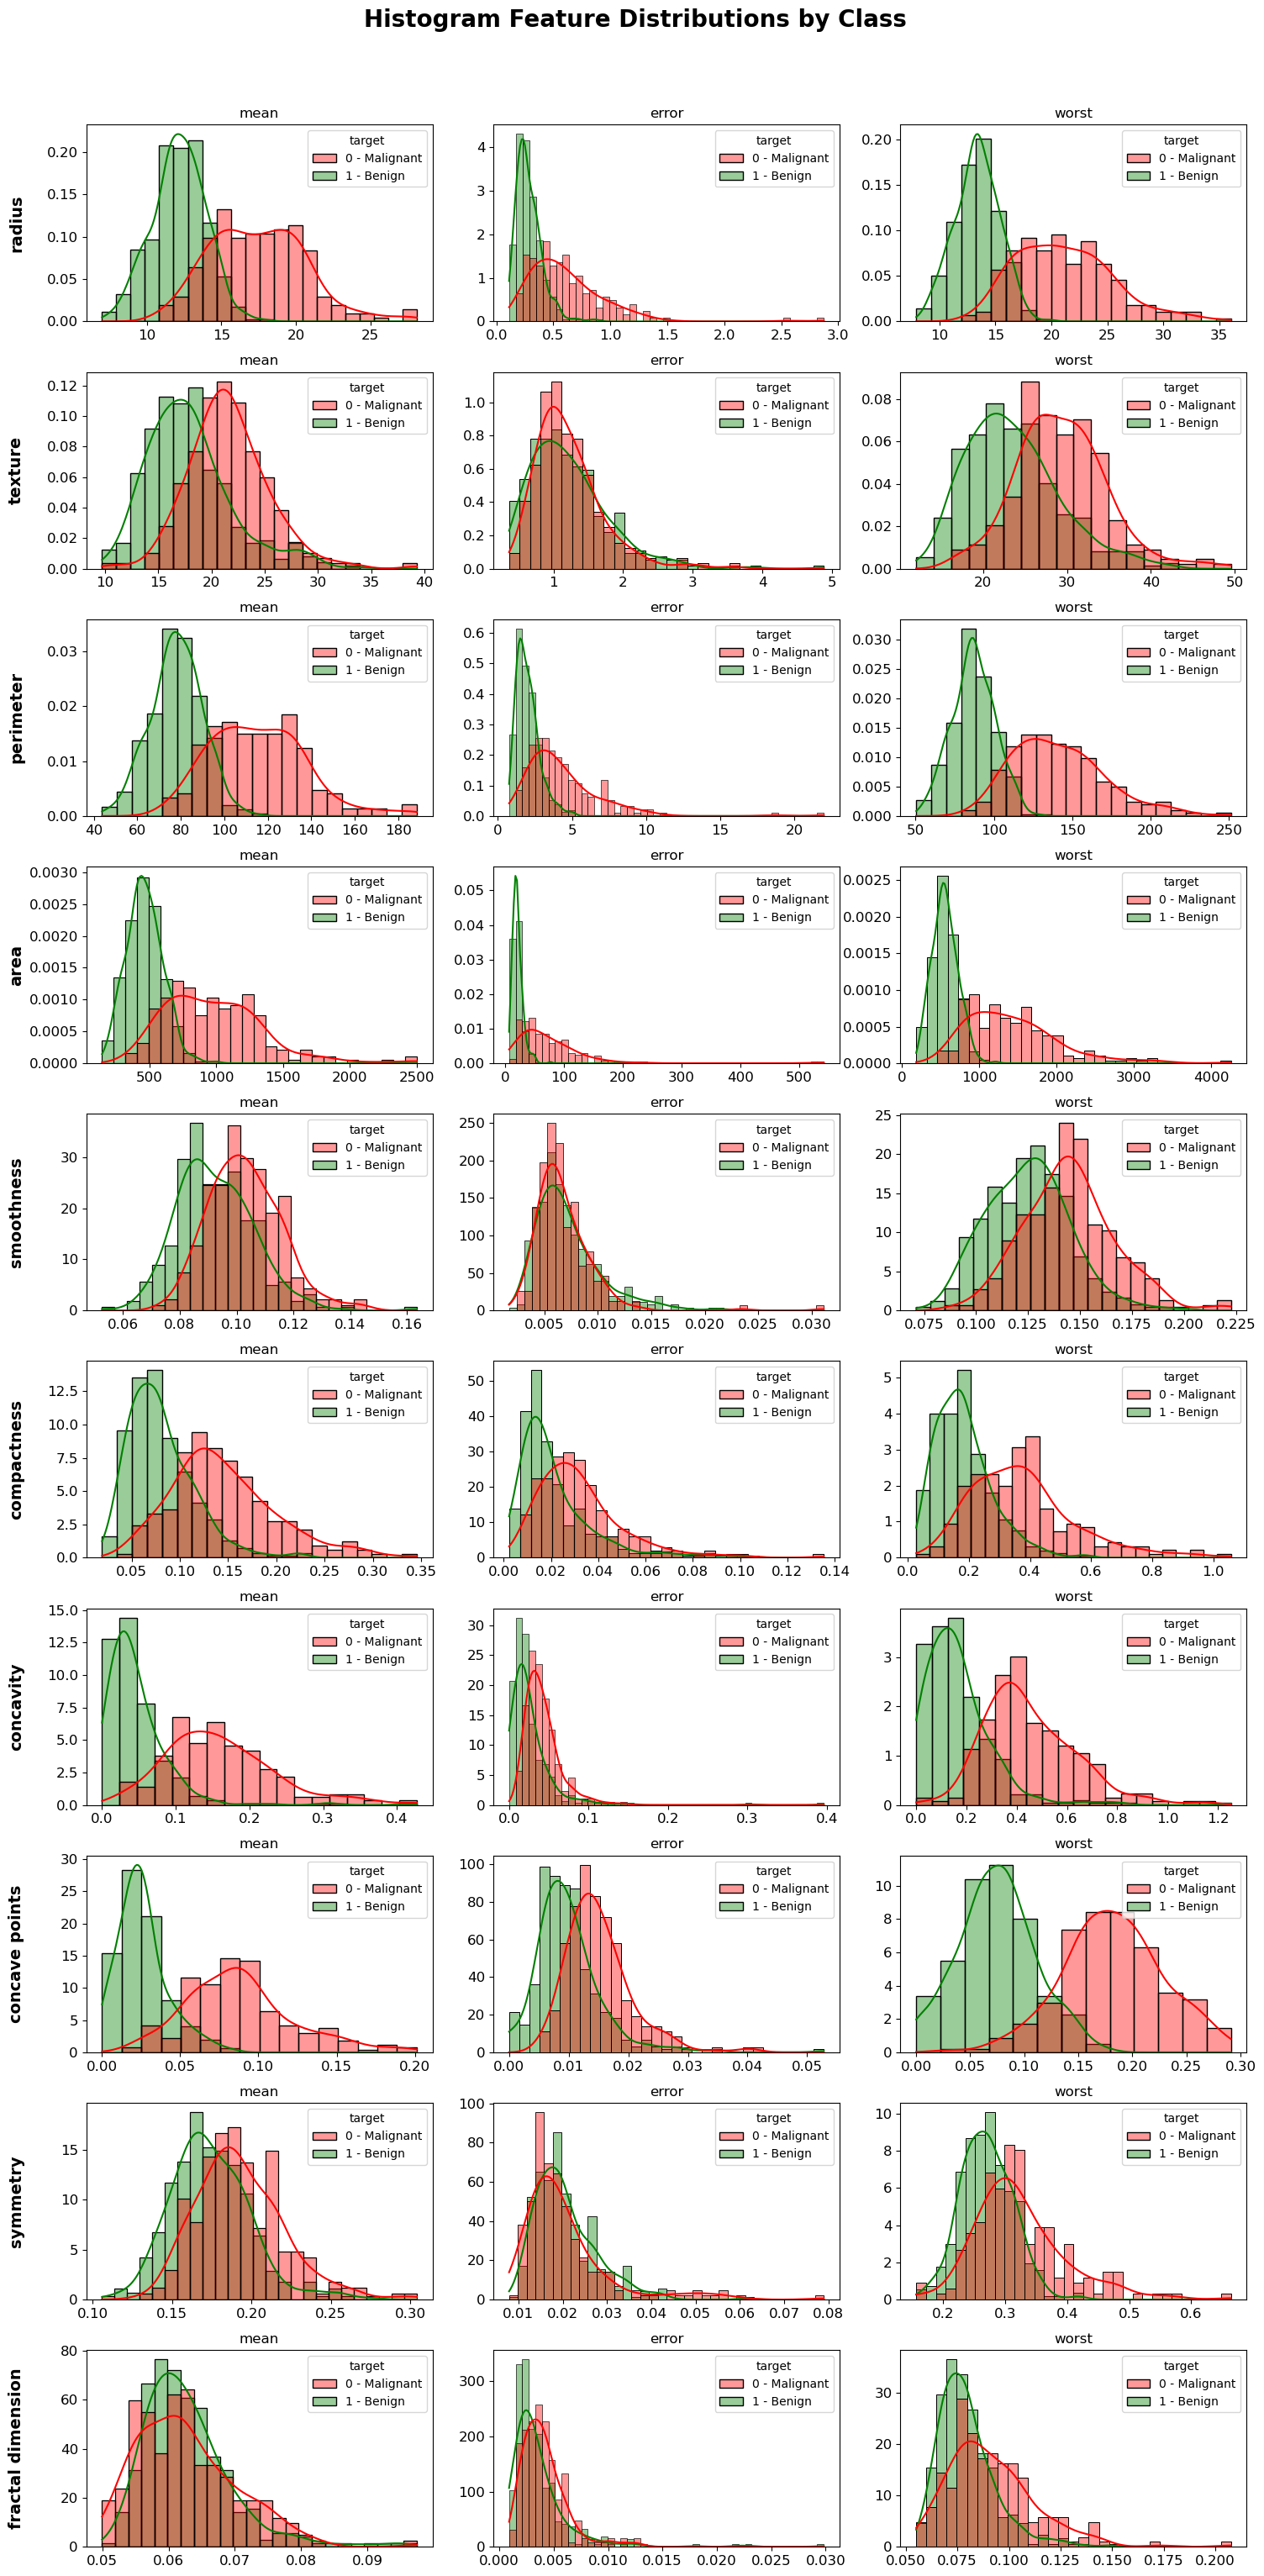

In [ ]:
fig, axes = plt.subplots(10, 3, figsize=(15, 30))
cat_y = y.map({0: '0 - Malignant', 1: '1 - Benign'})

base_features = [col.replace('mean ', '') for col in X.columns if col.startswith('mean ')] # detect base feature names by removing 'mean ' prefix

# Plot histograms in a matrix layout: rows for base features, columns for mean/error/worst
for i, base_name in enumerate(base_features):

    col_mean = f"mean {base_name}"
    col_error = f"{base_name} error"
    col_worst = f"worst {base_name}"

    cols_to_plot = [col_mean, col_error, col_worst]

    for j, col_name in enumerate(cols_to_plot):

        sns.histplot(
            data=X,
            x=col_name,
            hue=cat_y,
            stat='density', # Show density instead of count
            common_norm=False, # Normalize each class separately.
            ax=axes[i, j],
            kde=True, # Add KDE curve
            palette={'0 - Malignant': 'red', '1 - Benign': 'green'},
            alpha=0.4
        )

        if j == 0:
            axes[i, j].set_title("mean")
        elif j == 1:
            axes[i, j].set_title("error")
        elif j == 2:
            axes[i, j].set_title("worst")

        axes[i, j].tick_params(labelsize=12)  
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel(base_name if j == 0 else '', fontsize=14, fontweight='bold') # just label y-axis for the first column

fig.suptitle('Histogram Feature Distributions by Class', fontsize=20, fontweight='bold', y=1.02)
fig.align_ylabels()
fig.tight_layout()
plt.show(fig)

**Observations:**


### Boxplots

Matrix Layout: rows for base features, columns for mean/error/worst.

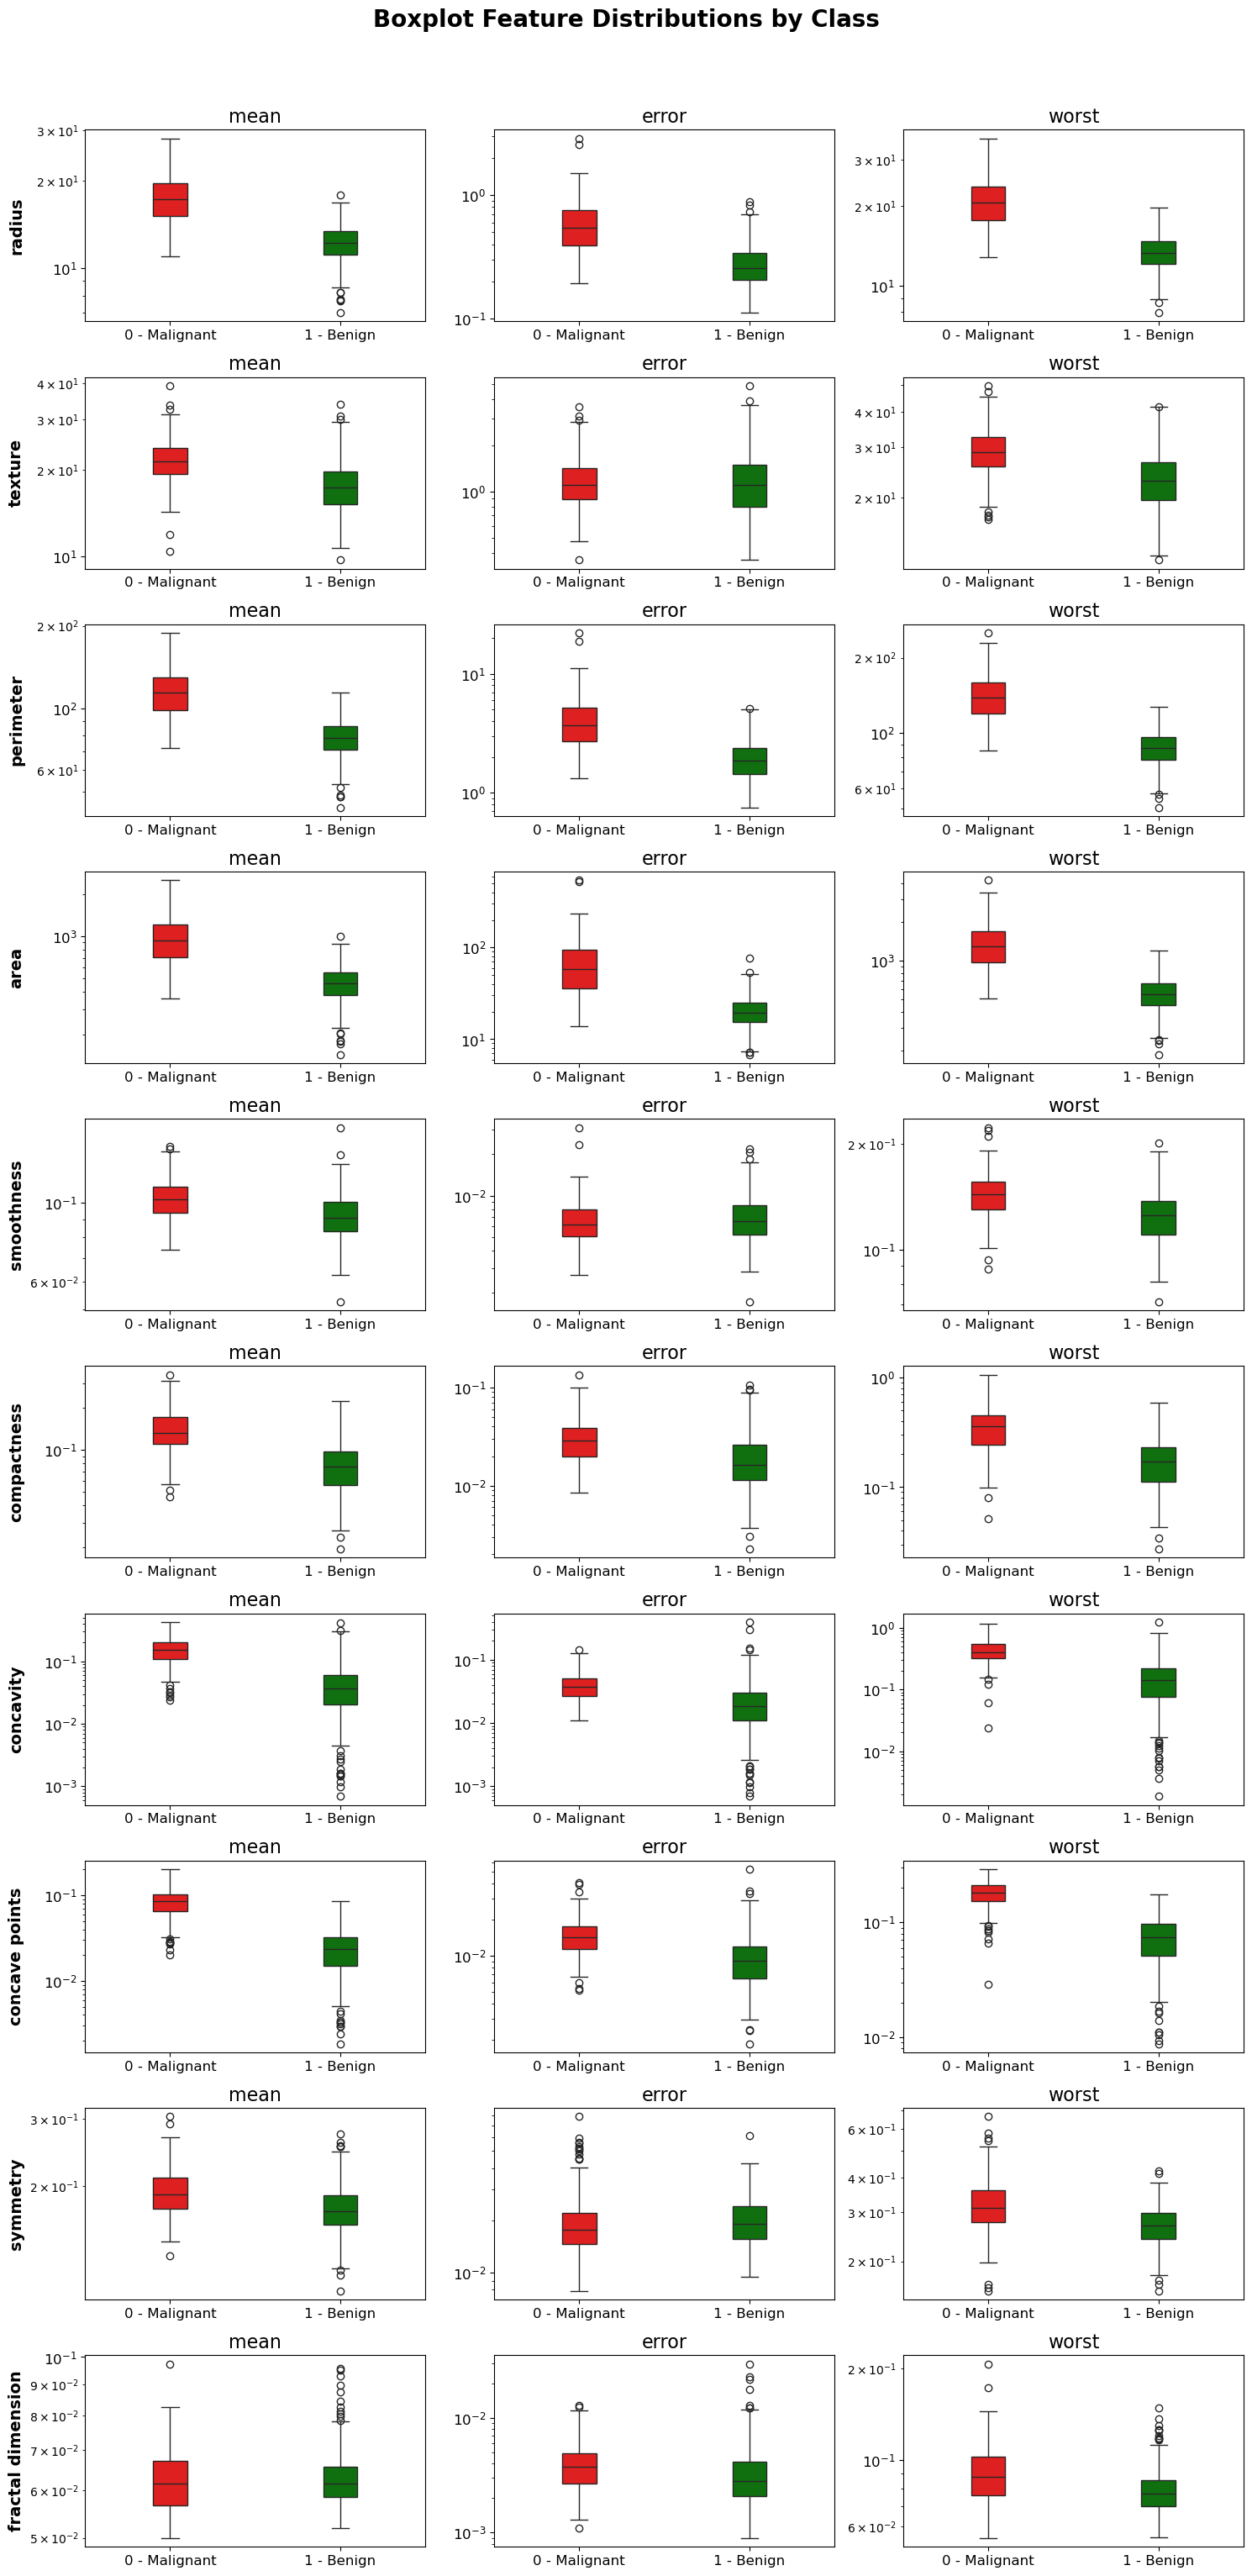

In [115]:
fig, axes = plt.subplots(10, 3, figsize=(15, 30))
cat_y = y.map({0: '0 - Malignant', 1: '1 - Benign'})

base_features = [col.replace('mean ', '') for col in X.columns if col.startswith('mean ')] # detect base feature names by removing 'mean ' prefix

# Plot boxplots in a matrix layout: rows for base features, columns for mean/error/worst
for i, base_name in enumerate(base_features):

    col_mean = f"mean {base_name}"
    col_error = f"{base_name} error"
    col_worst = f"worst {base_name}"

    cols_to_plot = [col_mean, col_error, col_worst]

    for j, col_name in enumerate(cols_to_plot):

        sns.boxplot(
            data=X,
            x=cat_y,
            hue=cat_y,
            palette={'0 - Malignant': 'red', '1 - Benign': 'green'},
            y = col_name,
            width=0.2,
            ax=axes[i, j],
            log_scale=True
        )


        if j == 0:
            axes[i, j].set_title("mean", fontsize=16)
        elif j == 1:
            axes[i, j].set_title("error", fontsize=16)
        elif j == 2:
            axes[i, j].set_title("worst", fontsize=16)

        axes[i, j].tick_params(labelsize=12)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel(base_name if j == 0 else '', fontsize=14, fontweight='bold') # just label y-axis for the first column

fig.suptitle('Boxplot Feature Distributions by Class', fontsize=20, fontweight='bold', y=1.02)
fig.align_ylabels()
fig.tight_layout()
plt.show(fig)

**Observations:**


### Correlation Heatmap

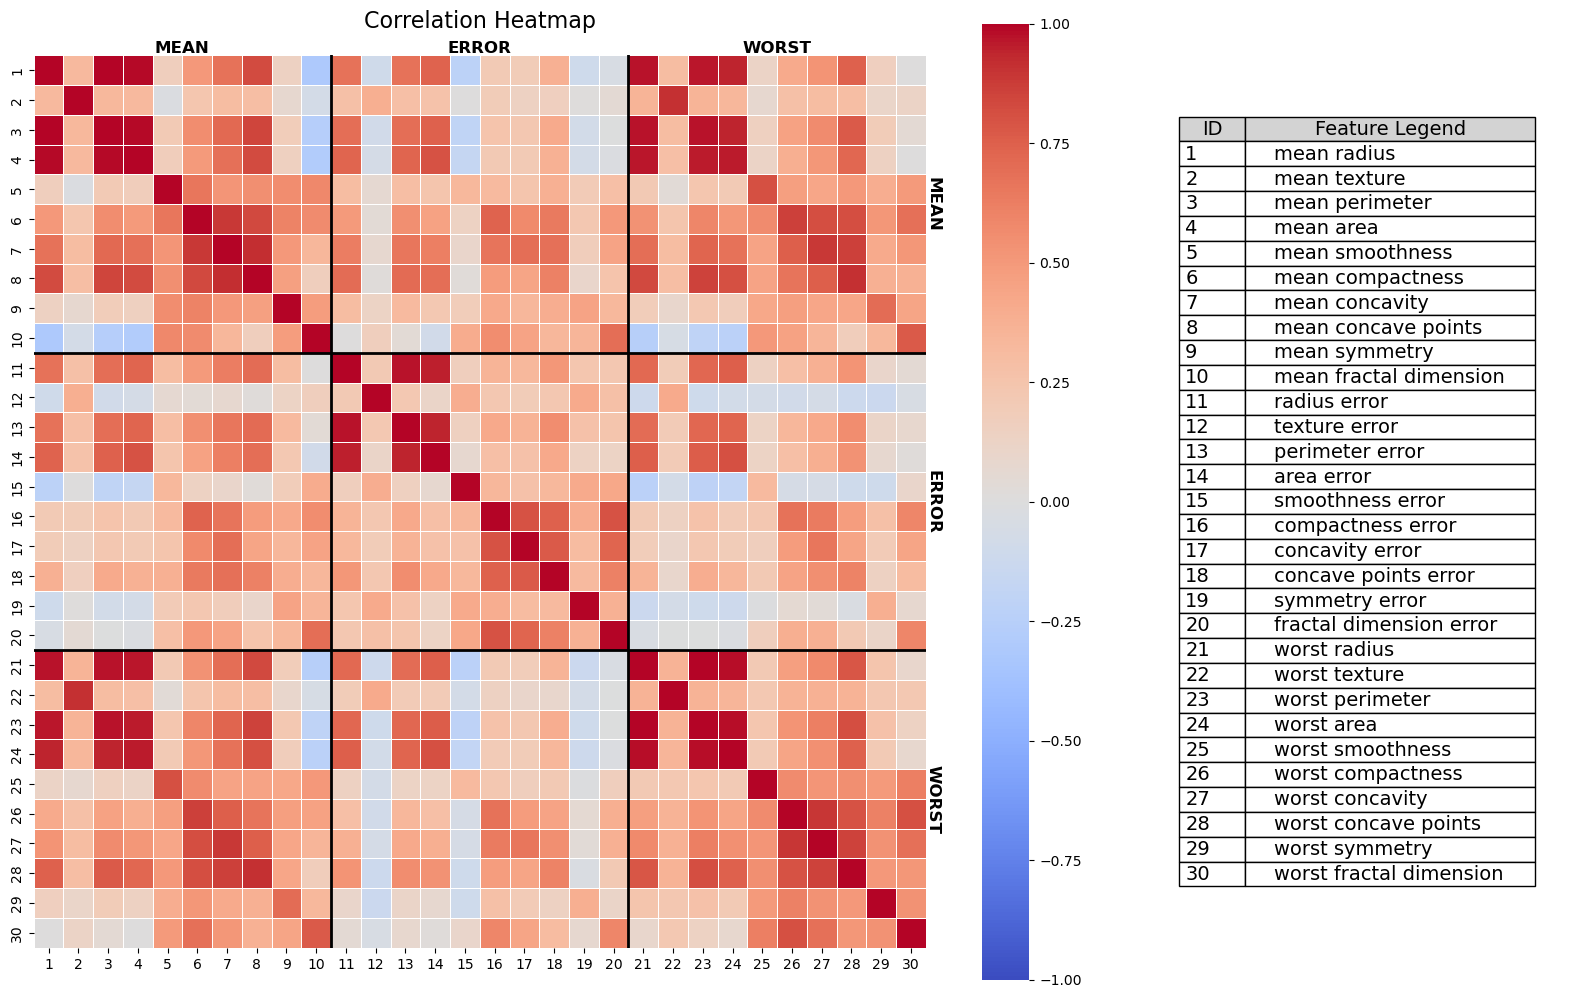

In [70]:
corr_matrix = X.corr()
dict_features = {i+1: name for i, name in enumerate(corr_matrix.columns)}

fig, (ax_heatmap, ax_legend) = plt.subplots(1, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [2.5, 1]})

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',          # Red for positive, blue for negative correlations
    vmax=1.0, vmin=-1.0,      # Fix the range of the color scale
    center=0,                 # The white will be exactly at 0 (no correlation)
    annot=False,              # False to not show the 900 numbers
    square=True,              # Makes each cell square
    linewidths=0.5,           # Small line of separation between cells
    xticklabels=list(dict_features.keys()),
    yticklabels=list(dict_features.keys()),
    ax = ax_heatmap
)
line_style = {'color': 'black', 'linewidth': 2}
ax_heatmap.axvline(x=10, **line_style)  # Vertical line after the 10th feature
ax_heatmap.axvline(x=20, **line_style)  # Vertical line after the 20th feature
ax_heatmap.axhline(y=10, **line_style)  # Horizontal line after the 10th feature
ax_heatmap.axhline(y=20, **line_style)  # Horizontal line after the 20th feature

text_style_v = {'ha': 'center', 'va': 'bottom', 'fontweight': 'bold', 'fontsize': 12}
ax_heatmap.text(5, 0, 'MEAN', **text_style_v)
ax_heatmap.text(15, 0, 'ERROR', **text_style_v)
ax_heatmap.text(25, 0, 'WORST', **text_style_v)

text_style_h = {'rotation': 270, 'va': 'center', 'ha': 'left', 'fontweight': 'bold', 'fontsize': 12}
ax_heatmap.text(30, 5, 'MEAN', **text_style_h)
ax_heatmap.text(30, 15, 'ERROR', **text_style_h)
ax_heatmap.text(30, 25, 'WORST', **text_style_h)

ax_heatmap.set_title('Correlation Heatmap', fontsize=16, pad=20)
ax_legend.axis('off')  # Hide the axis for the legend


legend = ax_legend.table(
    cellText=[[key, value] for key, value in dict_features.items()],
    colLabels=["ID", "Feature Legend"],
    loc='center',
    cellLoc='left',
    colColours=["lightgrey", "lightgrey"],
    colWidths=[0.15, 0.65]
)
legend.auto_set_font_size(False)
legend.set_fontsize(14)
legend.scale(1, 1.2)  # Scale the legend for better readability

plt.tight_layout()
plt.show()

**Discussion of top correlatied features:**


# Task 2 - Preprocessing & Feature Analysis

## 2.1. Split

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Proportion of classes in y_train:\n{y_train.value_counts(normalize=True).round(3)*100}%")
print(f"Training set size: {X_train.shape[0]} samples")

print(f"\nProportion of classes in y_test:\n{y_test.value_counts(normalize=True).round(3)*100}%")
print(f"Testing set size: {X_test.shape[0]} samples")

Proportion of classes in y_train:
target
1    62.6
0    37.4
Name: proportion, dtype: float64%
Training set size: 455 samples

Proportion of classes in y_test:
target
1    63.2
0    36.8
Name: proportion, dtype: float64%
Testing set size: 114 samples


## 2.2 Scaling

In [138]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(f"Mean of first 5 features (should be close to 0):\n{X_train_scaled.iloc[:, :5].mean().round(3)}")
print(f"Mean of the mean of all features: {X_train_scaled.mean().mean().round(3)}")
print(f"\nStandard deviation of first 5 features (should be close to 1):\n{X_train_scaled.iloc[:, :5].std().round(3)}")
print(f"Mean of standard deviations of all features: {X_train_scaled.std().mean().round(3)}")

Mean of first 5 features (should be close to 0):
mean radius       -0.0
mean texture       0.0
mean perimeter    -0.0
mean area         -0.0
mean smoothness    0.0
dtype: float64
Mean of the mean of all features: 0.0

Standard deviation of first 5 features (should be close to 1):
mean radius        1.001
mean texture       1.001
mean perimeter     1.001
mean area          1.001
mean smoothness    1.001
dtype: float64
Mean of standard deviations of all features: 1.001


## 2.2. Feature Analysis